In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
sepnum = "4"
fdir = "/home/cmp/Documents/Github/QPI-Scattering/CAnalytics/Calculations/250721Condensed_300_100ev/sep20a/sum_ldos.csv"

In [79]:
df = pd.read_csv(fdir, skiprows=1, header=None)

In [80]:
a = 0.24595 #nm
acc = 0.142
h = acc * np.tan(np.pi/3)
sep = int(sepnum)


xlin = np.linspace(-6, 6, 301)
ylin = np.linspace(-6, 6, 301)
X, Y = np.meshgrid(xlin, ylin)

In [81]:
def makeLog(Z):
    return np.log(Z + np.abs(np.min(Z)) + 1)

Text(0, 0.5, 'y (nm)')

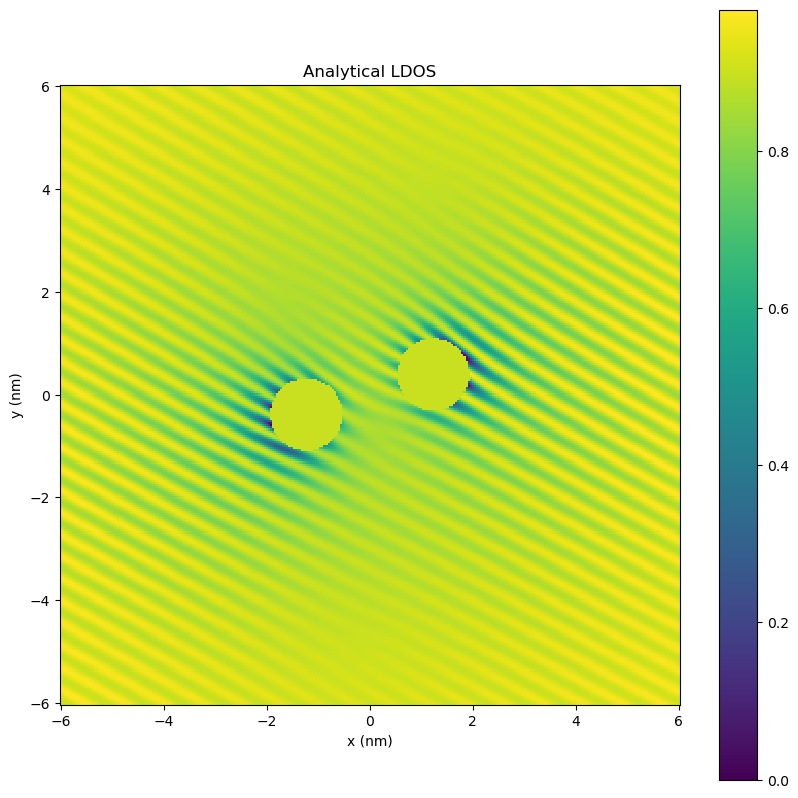

In [82]:
#xa = 1.17
#ya = 0.32

xa = 1.23
ya = 0.39

# We create a mask because our functions blow up at r -> zero
maskr = 0.7
mask1 = ((X+xa) ** 2 + (Y+ya) ** 2) <= maskr**2
mask2 = ((X-xa) ** 2 + (Y-ya) ** 2) <= maskr**2

mask = mask1 | mask2

Z_masked = df.values
Z_masked[mask] = 1e-9

ZR = Z_masked * ((X+xa) ** 2 + (Y+ya) ** 2 + (X-xa) ** 2 + (Y-ya) ** 2)

fig, ax = plt.subplots(figsize=(10, 10))

#pc = ax.pcolormesh(xlin, ylin, ZR2, cmap="winter", vmax=15, vmin=-15)
#pc = ax.pcolormesh(xlin, ylin, Z_masked, cmap="winter", vmax=1.5)
pc = ax.pcolormesh(xlin, ylin, makeLog(ZR))
fig.colorbar(pc)

ax.set_title("Analytical LDOS")

ax.set_aspect('equal')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')

In [83]:
# Fourier Transform
Z_fft = np.fft.fft2(Z_masked)
Z_fft_shifted = np.fft.fftshift(Z_fft)
magnitude_spectrum = np.abs(Z_fft_shifted)

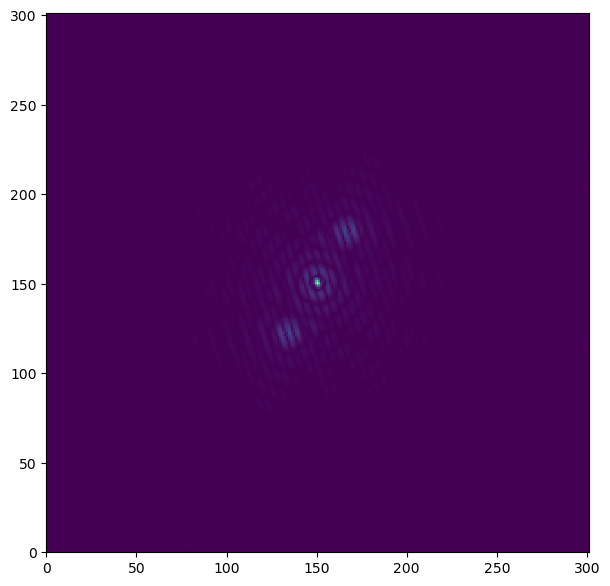

In [84]:
fig1, ax1 = plt.subplots(figsize=(7,7))

ax1.pcolormesh((magnitude_spectrum))